##datos sinteticos

In [2]:
import pandas as pd
import numpy as np
import random
import sdv
import sdmetrics

In [5]:
from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer

In [6]:
from sdmetrics.reports.single_table import QualityReport

In [11]:
print ("SDV: ", sdv.__version__)
print ("SDMetrics: ", sdmetrics.__version__)

SDV:  1.37.0
SDMetrics:  0.28.0


In [12]:
dfClientes = pd.DataFrame(
    {
        "cliente_id" : [1,2,3,4,5,6,7,8,9,10],
        "edad" : [17,18,19,25,32,42,70,28,23,22],
        "ingreso_mensual" : [1800,2000,2500,15000,18000,35000,7000,15000,4000,5000],
        "ciudad": ["Potrero Nuevo","Atoyac","Cuichapa","Cordoba","Cuitlahuac","Orizaba","Paraje","Yanga","Tierra Blanca","Cacahualco"]
    }
)

In [13]:
dfClientes


,cliente_id,edad,ingreso_mensual,ciudad
0,1,17,1800,Potrero Nuevo
1,2,18,2000,Atoyac
2,3,19,2500,Cuichapa
3,4,25,15000,Cordoba
4,5,32,18000,Cuitlahuac
5,6,42,35000,Orizaba
6,7,70,7000,Paraje
7,8,28,15000,Yanga
8,9,23,4000,Tierra Blanca
9,10,22,5000,Cacahualco


In [14]:
metadata = SingleTableMetadata()

In [15]:
metadata.detect_from_dataframe(
    data = dfClientes
)

In [18]:
metadata.to_dict()

{'columns': {'cliente_id': {'sdtype': 'id'},
  'edad': {'sdtype': 'numerical'},
  'ingreso_mensual': {'sdtype': 'numerical'},
  'ciudad': {'sdtype': 'categorical'}},
 'primary_key': 'cliente_id',
 'METADATA_SPEC_VERSION': 'SINGLE_TABLE_V1'}

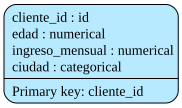

In [20]:
metadata.visualize()

In [21]:
sintetizador = GaussianCopulaSynthesizer(
    metadata
)

C:\Users\Mauri\anaconda3\envs\extracccion9avys\Lib\site-packages\sdv\single_table\base.py:182: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
C:\Users\Mauri\anaconda3\envs\extracccion9avys\Lib\site-packages\sdv\single_table\base.py:138: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


In [22]:
sintetizador.fit(
dfClientes
)

In [23]:
dfClientes_falsos = sintetizador.sample(
    num_rows=200
)

In [25]:
dfClientes_falsos


,cliente_id,edad,ingreso_mensual,ciudad
0,16169768,39,26390,Tierra Blanca
1,4918803,19,3912,Tierra Blanca
2,1900081,21,6413,Paraje
3,531516,20,2558,Paraje
4,10211768,37,14819,Cacahualco
...,...,...,...,...
195,1577423,18,6098,Cordoba
196,2804584,18,2049,Cuichapa
197,10420935,32,9982,Cacahualco
198,16659394,20,8847,Cacahualco


In [26]:
dfClientes_falsos.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   cliente_id       200 non-null    int64 
 1   edad             200 non-null    int64 
 2   ingreso_mensual  200 non-null    int64 
 3   ciudad           200 non-null    object
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


In [27]:
dfClientes_falsos.describe()

,cliente_id,edad,ingreso_mensual
count,2.000000e+02,200.000000,200.000000
mean,8.765887e+06,26.035000,10667.460000
std,4.707538e+06,12.553154,9166.046225
min,4.660500e+04,18.000000,2000.000000
25%,5.085226e+06,18.000000,2731.750000
50%,9.212590e+06,20.000000,7998.000000
75%,1.279456e+07,30.000000,16217.000000
max,1.677377e+07,70.000000,35000.000000


In [30]:
### Evaluamos los datos para validar

#Similitud entre las columnas (Columns Shapes Score)
#Similitud entre las relaciones de las columnas (Evaluating Column Per Trends)
#Evaluación del dataset general

In [34]:
reporte = QualityReport()


### Puntos de referencia

| Score | Interpretación |
|---|---|
| 1 | Idénticas |
| 0.9 | Muy similar |
| 0.7 | Similar |
| 0.6 | Diferencias visibles |
| < 0.5 | Muy diferentes |

In [33]:
reporte.generate (
    real_data = dfClientes,
    synthetic_data = dfClientes_falsos,
metadata = metadata.to_dict()
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 4/4 [00:00<00:00, 728.81it/s]|
Column Shapes Score: 74.83%

(2/2) Evaluating Column Pair Trends: |██████████| 6/6 [00:00<00:00, 200.49it/s]|
Column Pair Trends Score: 22.0%

Overall Score (Average): 48.42%

